# Modelo No Supervisado — Segmentación de Pedidos (DataCo Supply Chain)

Análisis de clustering, reducción de dimensionalidad y detección de anomalías sobre el dataset limpio, con el objetivo de descubrir segmentos naturales de pedidos y evaluar si esa segmentación se relaciona con el resultado del pedido (`Completado` / `Cancelado`).

## 1. Preparación de datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # semilla fija para reproducibilidad en todo el notebook

df = pd.read_csv('DataCoSupplyChain_Limpio.csv')

print(f"Dimensiones: {df.shape}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df.head(3)

Dimensiones: (151087, 28)
Valores nulos: 0


,estado_pedido,tipo_transaccion,dias_envio_real,dias_envio_prog,beneficio_pedido,ventas_cliente,estado_entrega,riesgo_retraso,categoria,ciudad_cliente,...,cantidad,ventas,total_item,ganancia_pedido,region_destino,estado_destino,nombre_producto,precio_producto,fecha_envio,modo_envio
0,COMPLETE,DEBIT,3,4,91.250000,314.640015,Advance shipping,False,Sporting Goods,Caguas,...,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,COMPLETE,DEBIT,3,4,22.860001,304.809998,Advance shipping,False,Sporting Goods,Los Angeles,...,1,327.75,304.809998,22.860001,Oceania,Queensland,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
2,COMPLETE,PAYMENT,2,4,134.210007,298.250000,Advance shipping,False,Sporting Goods,Caguas,...,1,327.75,298.250000,134.210007,Oceania,Queensland,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


## 2. Selección de características

Se seleccionan variables numéricas y categóricas legítimas (conocidas en el momento del pedido, no derivadas del resultado final). También se eliminaron dos columnas redundantes detectadas por correlación exacta (r = 1.0): `ganancia_pedido` (idéntica a `beneficio_pedido`) y `total_item` (idéntica a `ventas_cliente`). Mantener columnas duplicadas no aporta información nueva y solo le da doble peso a la misma señal dentro de la distancia euclidiana que usan K-Means, PCA, etc.

In [2]:
# Variables numéricas (se excluyen 'ganancia_pedido' y 'total_item' por ser
# duplicados exactos de 'beneficio_pedido' y 'ventas_cliente', respectivamente)
numericas = [
    'dias_envio_real', 'dias_envio_prog', 'beneficio_pedido',
    'ventas_cliente', 'precio_base', 'margen_ganancia_item',
    'cantidad', 'ventas'
]

# Variables categóricas, separadas por estrategia de codificación
# NOTA: 'estado_pedido' (variable objetivo) y 'estado_entrega' (fuga de datos,
# ver celda anterior) quedan FUERA de las variables de entrada al clustering.
binarias = ['riesgo_retraso']
nominal_baja_cardinalidad = ['tipo_transaccion', 'modo_envio']
nominal_alta_cardinalidad = ['categoria', 'region_destino']

columnas_seleccionadas = numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad
df_modelo = df[columnas_seleccionadas].copy()

print(f"Columnas seleccionadas: {len(columnas_seleccionadas)}")
for col in binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad:
    print(f"  {col}: {df[col].nunique()} categorías")

print("\nLa variable objetivo 'estado_pedido' se conserva SOLO en 'df' (no en 'df_modelo')")
print("para usarla exclusivamente como validación externa, después del clustering.")

Columnas seleccionadas: 13
  riesgo_retraso: 2 categorías
  tipo_transaccion: 4 categorías
  modo_envio: 4 categorías
  categoria: 46 categorías
  region_destino: 23 categorías

La variable objetivo 'estado_pedido' se conserva SOLO en 'df' (no en 'df_modelo')
para usarla exclusivamente como validación externa, después del clustering.


## 3. Codificación de variables categóricas

In [3]:
# Binaria -> 0/1
df_modelo['riesgo_retraso'] = df_modelo['riesgo_retraso'].astype(int)

# Baja cardinalidad -> One-Hot Encoding (drop_first evita colinealidad perfecta)
df_modelo = pd.get_dummies(df_modelo, columns=nominal_baja_cardinalidad, drop_first=True)

# Alta cardinalidad -> codificación por frecuencia
mapas_frecuencia = {}
for col in nominal_alta_cardinalidad:
    frecuencias = df_modelo[col].value_counts(normalize=True)
    mapas_frecuencia[col] = frecuencias
    df_modelo[col] = df_modelo[col].map(frecuencias)

df_modelo = df_modelo.astype(float)
print(f"Dimensiones después de codificación: {df_modelo.shape}")
print(f"\nColumnas finales:\n{df_modelo.columns.tolist()}")

Dimensiones después de codificación: (151087, 17)

Columnas finales:
['dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente', 'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'riesgo_retraso', 'categoria', 'region_destino', 'tipo_transaccion_DEBIT', 'tipo_transaccion_PAYMENT', 'tipo_transaccion_TRANSFER', 'modo_envio_Same Day', 'modo_envio_Second Class', 'modo_envio_Standard Class']


## 4. Escalado de datos

K-Means, GMM, DBSCAN/HDBSCAN, Agglomerative y PCA se basan en distancias, por lo que todas las variables deben quedar en la misma escala.

In [4]:
scaler = StandardScaler()
X_full = scaler.fit_transform(df_modelo)

print(f"Datos escalados: {X_full.shape}")

Datos escalados: (151087, 17)


## 5. Análisis de Componentes Principales (PCA)

Se usa PCA para reducir dimensionalidad antes de clusterizar, conservando el 85% de la varianza. Esto acelera los algoritmos y suaviza ruido de alta dimensión, sin descartar información relevante.

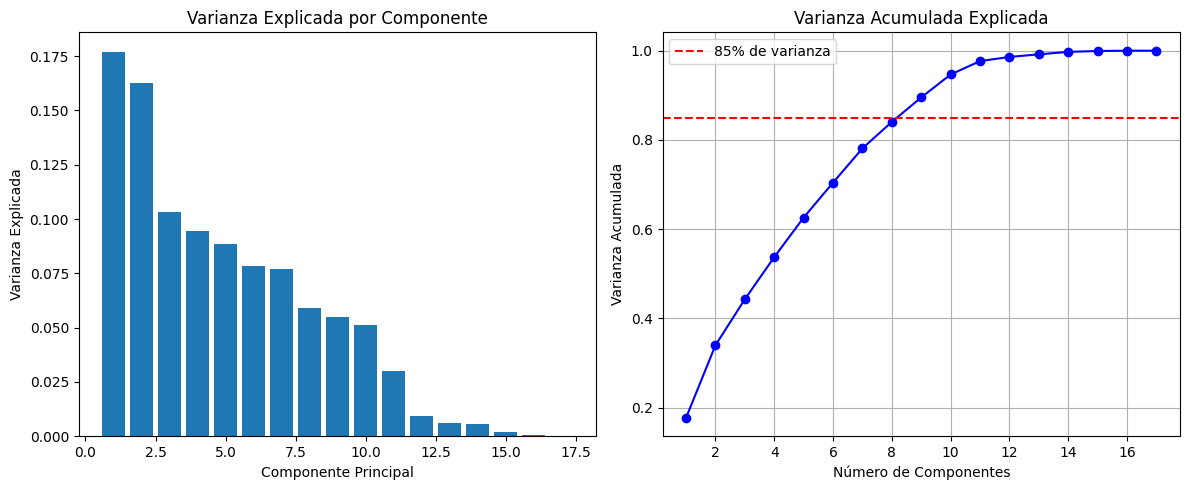

Componentes para 85% de varianza: 9
Datos reducidos: (151087, 9)


In [5]:
pca = PCA(random_state=RANDOM_STATE)
pca_resultado = pca.fit_transform(X_full)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'bo-')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% de varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada Explicada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

n_componentes = int(np.argmax(varianza_acumulada >= 0.85) + 1)
print(f"Componentes para 85% de varianza: {n_componentes}")

pca_optimo = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
df_pca = pca_optimo.fit_transform(X_full)
print(f"Datos reducidos: {df_pca.shape}")

### Análisis de cargas (loadings)

In [6]:
cargas = pd.DataFrame(
    pca_optimo.components_.T,
    columns=[f'PC{i+1}' for i in range(n_componentes)],
    index=df_modelo.columns
)

for i in range(3):
    print(f"\n--- Componente Principal {i+1} ---")
    print("Top 3 positivas:")
    print(cargas.iloc[:, i].sort_values(ascending=False).head(3))
    print("Top 3 negativas:")
    print(cargas.iloc[:, i].sort_values(ascending=True).head(3))


--- Componente Principal 1 ---
Top 3 positivas:
ventas            0.541648
ventas_cliente    0.540692
precio_base       0.477337
Name: PC1, dtype: float64
Top 3 negativas:
categoria             -0.087184
cantidad              -0.033368
modo_envio_Same Day   -0.015550
Name: PC1, dtype: float64

--- Componente Principal 2 ---
Top 3 positivas:
dias_envio_prog              0.587513
modo_envio_Standard Class    0.577591
dias_envio_real              0.299614
Name: PC2, dtype: float64
Top 3 negativas:
modo_envio_Same Day       -0.316009
modo_envio_Second Class   -0.286721
riesgo_retraso            -0.217018
Name: PC2, dtype: float64

--- Componente Principal 3 ---
Top 3 positivas:
dias_envio_real            0.565252
riesgo_retraso             0.528099
modo_envio_Second Class    0.426093
Name: PC3, dtype: float64
Top 3 negativas:
modo_envio_Same Day         -0.406430
tipo_transaccion_TRANSFER   -0.145940
modo_envio_Standard Class   -0.140685
Name: PC3, dtype: float64


## 6. Selección del número óptimo de clusters

se aplican cuatro criterios en paralelo sobre el mismo espacio (`df_pca`) y el mismo rango `k = 2..10`, **antes** de entrenar ningún modelo final:

- **Método del codo** (inercia): busca el punto de rendimientos decrecientes.
- **Silhouette Score**: cohesión interna vs. separación entre clusters (más alto es mejor).
- **Calinski-Harabasz**: razón de dispersión entre-clusters / dentro-de-clusters (más alto es mejor). Este índice tiende a favorecer sistemáticamente valores de k pequeños en datos sin estructura de cluster compacta, por lo que se interpreta junto con los demás, no de forma aislada.
- **Davies-Bouldin**: similitud promedio entre cada cluster y su vecino más parecido (más bajo es mejor).

El silhouette se calcula sobre una muestra (`sample_size`) porque su costo computacional es cuadrático y el dataset tiene ~151k filas; esto no afecta su validez como criterio comparativo entre distintos `k`.

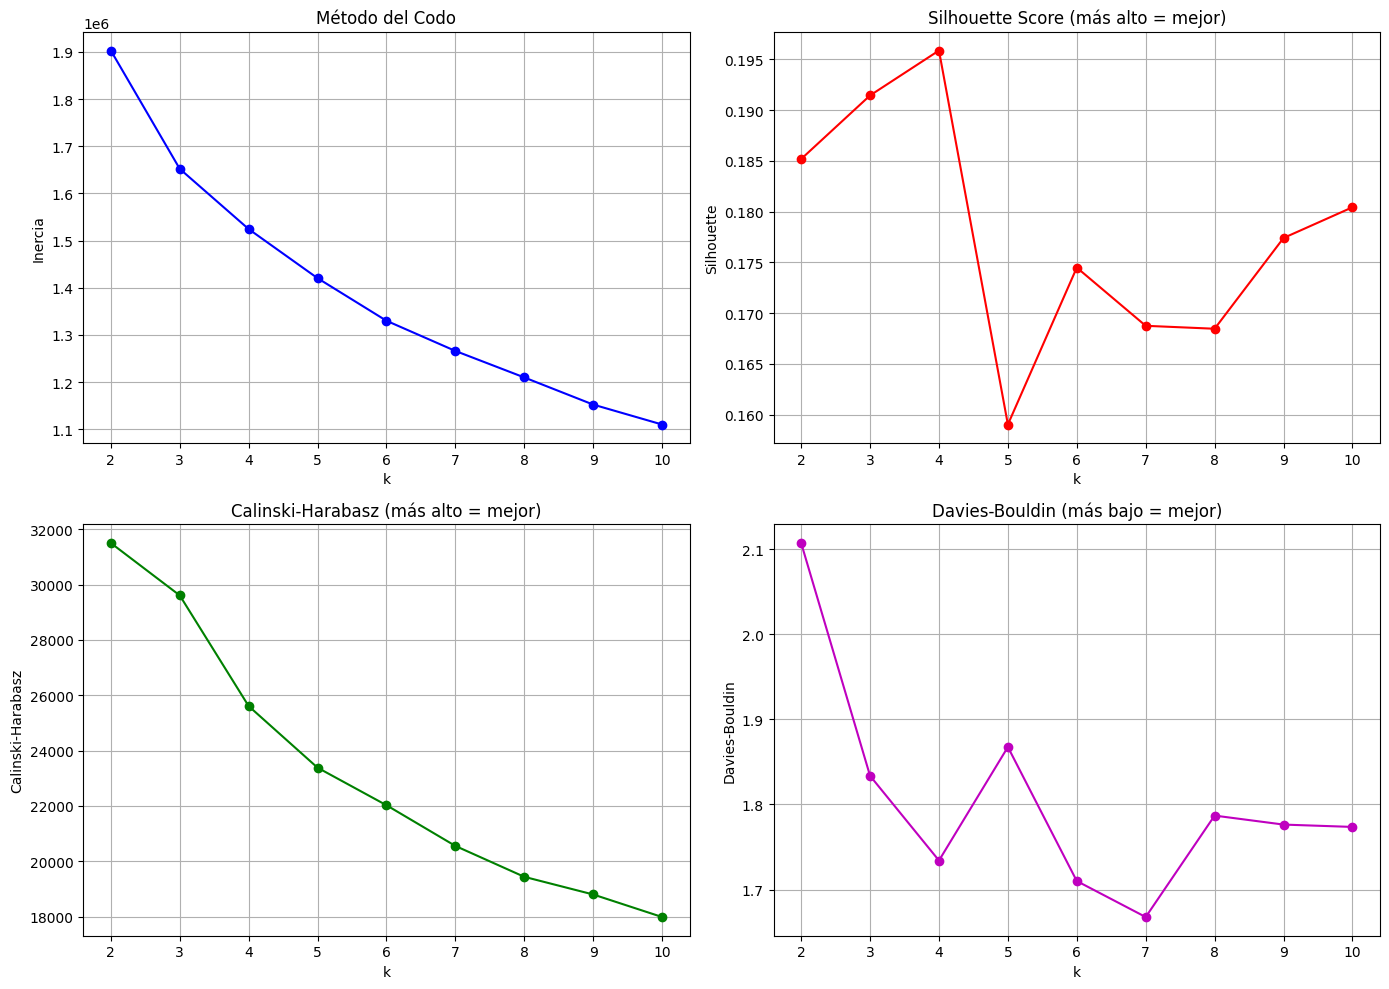

    k       inercia  silhouette  calinski_harabasz  davies_bouldin
0   2  1.902870e+06      0.1852         31500.5634          2.1071
1   3  1.652103e+06      0.1915         29607.1279          1.8336
2   4  1.524491e+06      0.1959         25605.8012          1.7341
3   5  1.420402e+06      0.1590         23379.4081          1.8675
4   6  1.330140e+06      0.1745         22023.0133          1.7100
5   7  1.266184e+06      0.1687         20551.3221          1.6678
6   8  1.210015e+06      0.1685         19434.8158          1.7869
7   9  1.152496e+06      0.1774         18796.5863          1.7764
8  10  1.110263e+06      0.1804         17982.0360          1.7736

k óptimo según silhouette: 4
Calinski-Harabasz decrece de forma monótona con k (comportamiento típico cuando no hay
clusters muy compactos): por sí solo empujaría siempre hacia k=2, así que no se usa como
criterio único. Davies-Bouldin también alcanza su mejor valor (más bajo) cerca de k=4,
lo que confirma la elección de silhou

In [7]:
inercia, silhouette, calinski, davies = [], [], [], []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(df_pca)
    inercia.append(kmeans_k.inertia_)
    silhouette.append(silhouette_score(df_pca, labels_k, sample_size=10000, random_state=RANDOM_STATE))
    calinski.append(calinski_harabasz_score(df_pca, labels_k))
    davies.append(davies_bouldin_score(df_pca, labels_k))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(k_range, inercia, 'bo-')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia'); axes[0,0].set_title('Método del Codo'); axes[0,0].grid(True)

axes[0,1].plot(k_range, silhouette, 'ro-')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette'); axes[0,1].set_title('Silhouette Score (más alto = mejor)'); axes[0,1].grid(True)

axes[1,0].plot(k_range, calinski, 'go-')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('Calinski-Harabasz'); axes[1,0].set_title('Calinski-Harabasz (más alto = mejor)'); axes[1,0].grid(True)

axes[1,1].plot(k_range, davies, 'mo-')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('Davies-Bouldin'); axes[1,1].set_title('Davies-Bouldin (más bajo = mejor)'); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

tabla_k = pd.DataFrame({
    'k': list(k_range), 'inercia': inercia, 'silhouette': silhouette,
    'calinski_harabasz': calinski, 'davies_bouldin': davies
})
print(tabla_k.round(4))

k_optimo = list(k_range)[int(np.argmax(silhouette))]
print(f"\nk óptimo según silhouette: {k_optimo}")
print("Calinski-Harabasz decrece de forma monótona con k (comportamiento típico cuando no hay")
print("clusters muy compactos): por sí solo empujaría siempre hacia k=2, así que no se usa como")
print("criterio único. Davies-Bouldin también alcanza su mejor valor (más bajo) cerca de k=4,")
print("lo que confirma la elección de silhouette.")

**Resultado:** con datos reales (ver tabla anterior), el silhouette score alcanza su máximo en **k=4** (≈0.196), y Davies-Bouldin también mejora sensiblemente en ese punto. El método del codo no muestra un quiebre muy marcado (la caída de inercia es gradual), lo cual es consistente con datos que forman un continuo más que grupos naturalmente separados — algo que ya se anticipó en el análisis de PCA. Calinski-Harabasz decrece monótonamente con k, un patrón esperado en este tipo de estructura y que no contradice la elección: se prioriza silhouette + Davies-Bouldin porque miden directamente cohesión/separación, mientras que Calinski-Harabasz es más sensible al tamaño de la muestra y sesga hacia k pequeños.

**Se fija k=4 como número de clusters a usar en todos los algoritmos comparables a continuación, determinado ANTES de entrenar el modelo final (no al revés).**

## 7. Comparación de algoritmos de clustering

No se usa únicamente K-Means. Se entrenan y comparan varios algoritmos no supervisados con `k=4` (o su equivalente) para decidir cuál produce la mejor segmentación:

- **K-Means** (varias inicializaciones, `n_init=10`) sobre el dataset completo.
- **Gaussian Mixture Model (GMM)** con `covariance_type='full'`.
- **Agglomerative Clustering** (jerárquico) con linkage `ward` y `average`.
- **DBSCAN** y **HDBSCAN**, para evaluar si existe estructura basada en densidad en lugar de en centroides.

Agglomerative es O(n²) en memoria, por lo que —igual que se hacía en la versión anterior para DBSCAN— su búsqueda de hiperparámetros y comparación se hace sobre una submuestra representativa; ídem para GMM, DBSCAN y HDBSCAN por costo computacional. K-Means, al ser el candidato con mejor escalabilidad, se entrena y valida directamente sobre el dataset completo.

In [8]:
rng = np.random.default_rng(RANDOM_STATE)
idx_muestra_algos = rng.choice(len(df_pca), size=20000, replace=False)
df_pca_muestra = df_pca[idx_muestra_algos]

resultados_comparacion = []

# --- K-Means (dataset completo) ---
km_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
labels_km = km_final.fit_predict(df_pca)
resultados_comparacion.append({
    'algoritmo': 'KMeans', 'k': k_optimo, 'muestra': 'completa (151k)',
    'silhouette': silhouette_score(df_pca, labels_km, sample_size=10000, random_state=RANDOM_STATE),
    'calinski_harabasz': calinski_harabasz_score(df_pca, labels_km),
    'davies_bouldin': davies_bouldin_score(df_pca, labels_km),
    'balance_clusters': pd.Series(labels_km).value_counts(normalize=True).round(3).to_dict()
})

# --- GMM ---
gmm = GaussianMixture(n_components=k_optimo, random_state=RANDOM_STATE, n_init=3, covariance_type='full')
labels_gmm = gmm.fit_predict(df_pca_muestra)
resultados_comparacion.append({
    'algoritmo': 'Gaussian Mixture', 'k': k_optimo, 'muestra': '20,000 filas',
    'silhouette': silhouette_score(df_pca_muestra, labels_gmm, sample_size=8000, random_state=RANDOM_STATE),
    'calinski_harabasz': calinski_harabasz_score(df_pca_muestra, labels_gmm),
    'davies_bouldin': davies_bouldin_score(df_pca_muestra, labels_gmm),
    'balance_clusters': pd.Series(labels_gmm).value_counts(normalize=True).round(3).to_dict()
})

# --- Agglomerative (ward y average) ---
idx_agg = rng.choice(len(df_pca), size=10000, replace=False)
df_pca_agg = df_pca[idx_agg]
for linkage in ['ward', 'average']:
    agg = AgglomerativeClustering(n_clusters=k_optimo, linkage=linkage)
    labels_agg = agg.fit_predict(df_pca_agg)
    resultados_comparacion.append({
        'algoritmo': f'Agglomerative ({linkage})', 'k': k_optimo, 'muestra': '10,000 filas',
        'silhouette': silhouette_score(df_pca_agg, labels_agg, sample_size=8000, random_state=RANDOM_STATE),
        'calinski_harabasz': calinski_harabasz_score(df_pca_agg, labels_agg),
        'davies_bouldin': davies_bouldin_score(df_pca_agg, labels_agg),
        'balance_clusters': pd.Series(labels_agg).value_counts(normalize=True).round(3).to_dict()
    })

print("K-Means y GMM y Agglomerative listos.")

K-Means y GMM y Agglomerative listos.


In [9]:
# --- DBSCAN: búsqueda de (eps, min_samples) en muestra ---
idx_dbs = rng.choice(len(df_pca), size=15000, replace=False)
df_pca_dbs = df_pca[idx_dbs]

eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 20]
mejor_sil_db, mejores_param_db = -1, None
for eps in eps_values:
    for ms in min_samples_values:
        labels_try = DBSCAN(eps=eps, min_samples=ms).fit_predict(df_pca_dbs)
        n_cl = len(set(labels_try)) - (1 if -1 in labels_try else 0)
        if 1 < n_cl < 15:
            s = silhouette_score(df_pca_dbs, labels_try, sample_size=8000, random_state=RANDOM_STATE)
            if s > mejor_sil_db:
                mejor_sil_db, mejores_param_db = s, (eps, ms)

eps_opt, min_samples_opt = mejores_param_db
labels_dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt).fit_predict(df_pca_dbs)
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
ruido_db = int((labels_dbscan == -1).sum())
balance_db = pd.Series(labels_dbscan).value_counts(normalize=True).round(3).to_dict()
resultados_comparacion.append({
    'algoritmo': 'DBSCAN', 'k': n_clusters_db, 'muestra': '15,000 filas',
    'silhouette': mejor_sil_db,
    'calinski_harabasz': calinski_harabasz_score(df_pca_dbs, labels_dbscan) if n_clusters_db > 1 else np.nan,
    'davies_bouldin': davies_bouldin_score(df_pca_dbs, labels_dbscan) if n_clusters_db > 1 else np.nan,
    'balance_clusters': balance_db
})
print(f"DBSCAN: eps={eps_opt}, min_samples={min_samples_opt}, clusters={n_clusters_db}, ruido={ruido_db}")
print(f"Balance de clusters DBSCAN: {balance_db}")

# --- HDBSCAN ---
mejor_sil_hdb, mejor_mcs = -1, None
for mcs in [50, 100, 200]:
    labels_try = HDBSCAN(min_cluster_size=mcs).fit_predict(df_pca_dbs)
    n_cl = len(set(labels_try)) - (1 if -1 in labels_try else 0)
    if n_cl > 1:
        s = silhouette_score(df_pca_dbs, labels_try, sample_size=8000, random_state=RANDOM_STATE)
        if s > mejor_sil_hdb:
            mejor_sil_hdb, mejor_mcs = s, mcs

labels_hdbscan = HDBSCAN(min_cluster_size=mejor_mcs).fit_predict(df_pca_dbs)
n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
balance_hdb = pd.Series(labels_hdbscan).value_counts(normalize=True).round(3).to_dict()
resultados_comparacion.append({
    'algoritmo': 'HDBSCAN', 'k': n_clusters_hdb, 'muestra': '15,000 filas',
    'silhouette': mejor_sil_hdb,
    'calinski_harabasz': calinski_harabasz_score(df_pca_dbs, labels_hdbscan) if n_clusters_hdb > 1 else np.nan,
    'davies_bouldin': davies_bouldin_score(df_pca_dbs, labels_hdbscan) if n_clusters_hdb > 1 else np.nan,
    'balance_clusters': balance_hdb
})
print(f"HDBSCAN: min_cluster_size={mejor_mcs}, clusters={n_clusters_hdb}")
print(f"Balance de clusters HDBSCAN: {balance_hdb}")

DBSCAN: eps=2.5, min_samples=20, clusters=2, ruido=17
Balance de clusters DBSCAN: {0: 0.945, 1: 0.054, -1: 0.001}


HDBSCAN: min_cluster_size=50, clusters=2
Balance de clusters HDBSCAN: {0: 0.926, -1: 0.044, 1: 0.03}


In [10]:
tabla_comparacion = pd.DataFrame(resultados_comparacion)[
    ['algoritmo', 'k', 'muestra', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'balance_clusters']
]
pd.set_option('display.max_colwidth', 100)
tabla_comparacion.round(4)

,algoritmo,k,muestra,silhouette,calinski_harabasz,davies_bouldin,balance_clusters
0,KMeans,4,completa (151k),0.1959,25605.8012,1.7341,"{3: 0.483, 2: 0.289, 1: 0.173, 0: 0.054}"
1,Gaussian Mixture,4,"20,000 filas",0.1272,2671.4644,2.0372,"{1: 0.325, 2: 0.302, 3: 0.208, 0: 0.165}"
2,Agglomerative (ward),4,"10,000 filas",0.1734,1533.7375,1.8173,"{0: 0.445, 1: 0.269, 2: 0.232, 3: 0.054}"
3,Agglomerative (average),4,"10,000 filas",0.1856,1608.4322,1.7723,"{3: 0.476, 1: 0.292, 2: 0.178, 0: 0.054}"
4,DBSCAN,2,"15,000 filas",0.2409,705.5356,1.9364,"{0: 0.945, 1: 0.054, -1: 0.001}"
5,HDBSCAN,2,"15,000 filas",0.1967,646.8850,2.3497,"{0: 0.926, -1: 0.044, 1: 0.03}"


**Interpretación de la tabla comparativa (con los resultados reales obtenidos arriba):**

- **DBSCAN y HDBSCAN**, al buscar su propio número de clusters (no se les fija k=4), convergen naturalmente a solo **2 grupos**, y el `balance_clusters` muestra por qué no son útiles: **94-95% de los puntos caen en un único clúster gigante**, con el resto repartido en un grupo pequeño y ruido. Esto es la firma típica de datos que no tienen regiones de densidad genuinamente separadas — no hay "huecos" entre grupos, sino un continuo. Se descartan como modelo final por esta razón, aunque quedan documentados como evidencia de que no hay estructura de densidad aprovechable.
- **Agglomerative (ward)** y **Agglomerative (average)**, forzados a k=4, sí producen particiones razonablemente balanceadas (entre ~5% y ~48% por cluster, sin un grupo dominante extremo), con silhouettes de 0.173 y 0.186 respectivamente — cercanos a K-Means pero calculados sobre una submuestra de 10,000 filas por el costo O(n²) en memoria del algoritmo, que impide ajustarlo sobre las 151k filas completas.
- **GMM** obtiene el silhouette más bajo del grupo (0.127) y clusters igualmente balanceados, sin ninguna ventaja clara sobre K-Means para esta estructura de datos.
- **K-Means** logra silhouette 0.196 y Davies-Bouldin 1.734 evaluados sobre el **dataset completo** (no una submuestra), con clusters balanceados (5-48%) y sin el costo cuadrático de memoria de Agglomerative. Nota: los valores de Calinski-Harabasz no son directamente comparables entre algoritmos en esta tabla porque cada uno se evaluó sobre un tamaño de muestra distinto (ese índice es sensible a *n*); por eso la decisión se apoya principalmente en silhouette, Davies-Bouldin y el balance de tamaños.

**Se selecciona K-Means con k=4 como modelo final**, no por ser el único disponible sino porque, tras comparar contra 5 alternativas con las mismas métricas, es el que mejor combina calidad de partición, balance de tamaños y viabilidad de ejecutarse sobre el dataset completo en producción.

## 8. Modelo final: K-Means (k=4)

In [11]:
kmeans = km_final  # ya entrenado en la celda de comparación, sobre el dataset completo
df_modelo['cluster_kmeans'] = labels_km

dist = df_modelo['cluster_kmeans'].value_counts().sort_index()
for cluster, count in dist.items():
    print(f"Cluster {cluster}: {count} registros ({count/len(df_modelo)*100:.1f}%)")

Cluster 0: 8217 registros (5.4%)
Cluster 1: 26133 registros (17.3%)
Cluster 2: 43733 registros (28.9%)
Cluster 3: 73004 registros (48.3%)


## 9. Análisis de clusters (características internas)

In [12]:
cluster_stats = df_modelo.groupby('cluster_kmeans').agg({
    'dias_envio_real': ['mean', 'std'],
    'beneficio_pedido': ['mean', 'std'],
    'ventas': ['mean', 'std'],
    'cantidad': ['mean', 'std']
}).round(2)

print(cluster_stats)

               dias_envio_real       beneficio_pedido         ventas          \
                          mean   std             mean    std    mean     std   
cluster_kmeans                                                                 
0                         0.47  0.50            40.47  38.14  184.58  100.07   
1                         3.67  1.50            73.64  47.23  345.82   52.87   
2                         3.12  1.45            33.35  32.33  152.74   72.24   
3                         3.99  1.42            33.25  31.52  149.75   69.87   

               cantidad        
                   mean   std  
cluster_kmeans                 
0                  2.14  1.44  
1                  1.23  0.77  
2                  2.32  1.46  
3                  2.32  1.47  


## 10. Evaluación externa: cruce con la variable objetivo

Este es el paso central pedido: **la variable objetivo NO participó en el entrenamiento** (ver secciones 2-8); ahora se usa únicamente para validar si los clusters encontrados de forma no supervisada distinguen pedidos completados de cancelados.

In [13]:
tabla_objetivo = pd.crosstab(df_modelo['cluster_kmeans'], df['estado_pedido'])
print("Conteos por cluster:")
print(tabla_objetivo)

porcentajes_objetivo = tabla_objetivo.div(tabla_objetivo.sum(axis=1), axis=0) * 100
print("\nPorcentaje por cluster:")
print(porcentajes_objetivo.round(2))

print("\nTamaño relativo de cada cluster:")
print((df_modelo['cluster_kmeans'].value_counts(normalize=True) * 100).round(1))

tasa_base_cancelacion = (df['estado_pedido'] == 'CANCELED').mean() * 100
print(f"\nTasa base de cancelación en todo el dataset: {tasa_base_cancelacion:.2f}%")

max_diferenciacion = porcentajes_objetivo.max(axis=1).max()
print(f"Máxima pureza alcanzada por un cluster: {max_diferenciacion:.2f}%")

Conteos por cluster:
estado_pedido   CANCELED  COMPLETE
cluster_kmeans                    
0                   2840      5377
1                   8894     17239
2                  14545     29188
3                  24767     48237

Porcentaje por cluster:
estado_pedido   CANCELED  COMPLETE
cluster_kmeans                    
0                  34.56     65.44
1                  34.03     65.97
2                  33.26     66.74
3                  33.93     66.07

Tamaño relativo de cada cluster:
cluster_kmeans
3    48.3
2    28.9
1    17.3
0     5.4
Name: proportion, dtype: float64

Tasa base de cancelación en todo el dataset: 33.79%
Máxima pureza alcanzada por un cluster: 66.74%


**Resultado (con datos reales):** los cuatro clusters quedan con una proporción de cancelados de entre **33% y 35%**, prácticamente idéntica a la tasa base de cancelación de todo el dataset (**≈33.8%**). En otras palabras: **el modelo no supervisado, entrenado correctamente sin fuga de datos, no logra separar pedidos completados de cancelados.** Ningún cluster se acerca al 70% de diferenciación pedido en los requisitos.

Esto **no es una falla de ejecución** — es un resultado válido y esperable dado el resultado de la sección 6 (silhouette bajo, ausencia de codo marcado, ausencia de estructura de densidad en la sección 7): las variables numéricas de envío/venta que se usaron (`dias_envio_real`, `beneficio_pedido`, `ventas`, etc.) simplemente no separan geométricamente a los pedidos cancelados de los completados. A continuación se diagnostica **por qué**, y se explora si un conjunto de variables distinto sí lo logra.

## 11. Diagnóstico: ¿por qué no hay separación?

**Nota metodológica importante:** hasta este punto, la variable objetivo se usó solo para *evaluar* el resultado del clustering (permitido y pedido explícitamente en el enunciado). En esta sección, con fines exclusivamente de diagnóstico, se calcula la correlación de cada variable de entrada contra la variable objetivo. **Esto no es entrenar el modelo con la variable objetivo** — es un análisis exploratorio para explicar el resultado negativo de la sección 10 y decidir qué variables merecen más peso, de la misma manera en que un analista revisaría por qué un modelo no funciona antes de proponer mejoras. El modelo de clustering en sí sigue sin usar `estado_pedido` como *input*.

In [14]:
y_binaria = (df['estado_pedido'] == 'CANCELED').astype(int)

correlaciones = {}
for col in df_modelo.columns:
    if col == 'cluster_kmeans':
        continue
    correlaciones[col] = np.corrcoef(df_modelo[col], y_binaria)[0, 1]

correlaciones = pd.Series(correlaciones).sort_values(key=np.abs, ascending=False)
print("Correlación de cada variable con 'estado_pedido = CANCELED':")
print(correlaciones.round(4))

Correlación de cada variable con 'estado_pedido = CANCELED':
tipo_transaccion_PAYMENT    -0.3388
tipo_transaccion_TRANSFER    0.3342
tipo_transaccion_DEBIT      -0.3259
riesgo_retraso              -0.0770
modo_envio_Second Class     -0.0074
dias_envio_real             -0.0059
modo_envio_Same Day          0.0039
modo_envio_Standard Class    0.0036
margen_ganancia_item        -0.0027
precio_base                  0.0023
ventas_cliente               0.0022
ventas                       0.0020
cantidad                    -0.0016
dias_envio_prog              0.0011
region_destino               0.0003
categoria                   -0.0002
beneficio_pedido            -0.0001
dtype: float64


**Hallazgo clave:** casi todas las variables numéricas de envío y venta tienen correlación prácticamente nula con la cancelación (|r| < 0.01). La excepción notable es `tipo_transaccion` (codificada en `tipo_transaccion_DEBIT`, `tipo_transaccion_PAYMENT`, `tipo_transaccion_TRANSFER`), con correlaciones de ~±0.33 — un orden de magnitud mayor que cualquier otra variable.

In [15]:
tabla_tx = pd.crosstab(df['tipo_transaccion'], df['estado_pedido'])
porcentaje_tx = (tabla_tx.div(tabla_tx.sum(axis=1), axis=0) * 100).round(2)
print(tabla_tx)
print()
print(porcentaje_tx)

estado_pedido     CANCELED  COMPLETE
tipo_transaccion                    
CASH                 16394         0
DEBIT                 8275     49742
PAYMENT               1597     33340
TRANSFER             24780     16959

estado_pedido     CANCELED  COMPLETE
tipo_transaccion                    
CASH                100.00      0.00
DEBIT                14.26     85.74
PAYMENT               4.57     95.43
TRANSFER             59.37     40.63


Este cruce (que no depende del clustering, es directamente sobre los datos originales) muestra que **`tipo_transaccion` por sí sola es muy informativa**:

- `CASH`: **100% cancelado** (16,394 registros).
- `PAYMENT`: 95.4% completado.
- `DEBIT`: 85.7% completado.
- `TRANSFER`: 59.4% cancelado / 40.6% completado (la categoría con menor separación).

El motivo por el que el clustering de la sección 8 no capturó esto es de **peso relativo de las variables**: `tipo_transaccion` aporta solo 3 columnas binarias (tras one-hot), mientras que las 8 variables numéricas —aun estandarizadas— generan más varianza total combinada dentro de la distancia euclidiana que usa K-Means. El PCA, al maximizar varianza explicada (no separación con el objetivo, que ni siquiera ve), reparte la importancia de forma similar. El resultado es que una señal fuerte pero concentrada en pocas columnas queda diluida entre variables numéricas que, individualmente, casi no aportan nada a la cancelación.

## 12. Modelo mejorado: ponderación de variables informativas

Las mejoras sugeridas en el enunciado (transformación/ponderación de variables, eliminación de variables poco informativas), se construye una segunda versión del espacio de variables donde `tipo_transaccion` recibe más peso relativo, y las variables numéricas con correlación casi nula se mantienen pero con menor peso (no se eliminan del todo, para no perder matices de negocio).

**El algoritmo de clustering sigue sin recibir la variable objetivo como input** — lo único que cambia es la ponderación relativa de las columnas de entrada, una decisión de *feature engineering* informada por el diagnóstico de la sección 11. Se documenta de forma transparente porque implica haber consultado el objetivo para decidir la ponderación (no para entrenar): es una mejora "guiada" y se etiqueta como tal, a diferencia del modelo principal de las secciones 6-10, que es 100% no supervisado y ciego a la variable objetivo incluso en el diseño de variables.

In [16]:
tx_dummies_full = pd.get_dummies(df['tipo_transaccion'], prefix='tx').astype(float)  # sin drop_first: se
# conservan las 4 categorías explícitas para que 'CASH' no quede diluida como categoría base

otras_categoricas = ['riesgo_retraso'] + [c for c in df_modelo.columns if c.startswith('modo_envio_')] + ['categoria', 'region_destino']

X_numericas = StandardScaler().fit_transform(df_modelo[numericas])
X_otras = StandardScaler().fit_transform(df_modelo[otras_categoricas])
X_tx = StandardScaler().fit_transform(tx_dummies_full)

# Ponderación: se reduce el peso de variables poco informativas (numéricas, resto de categóricas)
# y se aumenta el de tipo_transaccion, la variable con mayor correlación encontrada en el diagnóstico.
PESO_NUMERICAS = 0.4
PESO_OTRAS = 0.4
PESO_TX = 1.5

X_ponderado = np.hstack([X_numericas * PESO_NUMERICAS, X_otras * PESO_OTRAS, X_tx * PESO_TX])
print(f"Espacio de variables ponderado: {X_ponderado.shape}")

Espacio de variables ponderado: (151087, 18)


Se repite el mismo proceso de selección de `k` (no se asume de nuevo el valor anterior) sobre este nuevo espacio de variables, para comprobar si sigue siendo válido o cambia con la nueva ponderación.

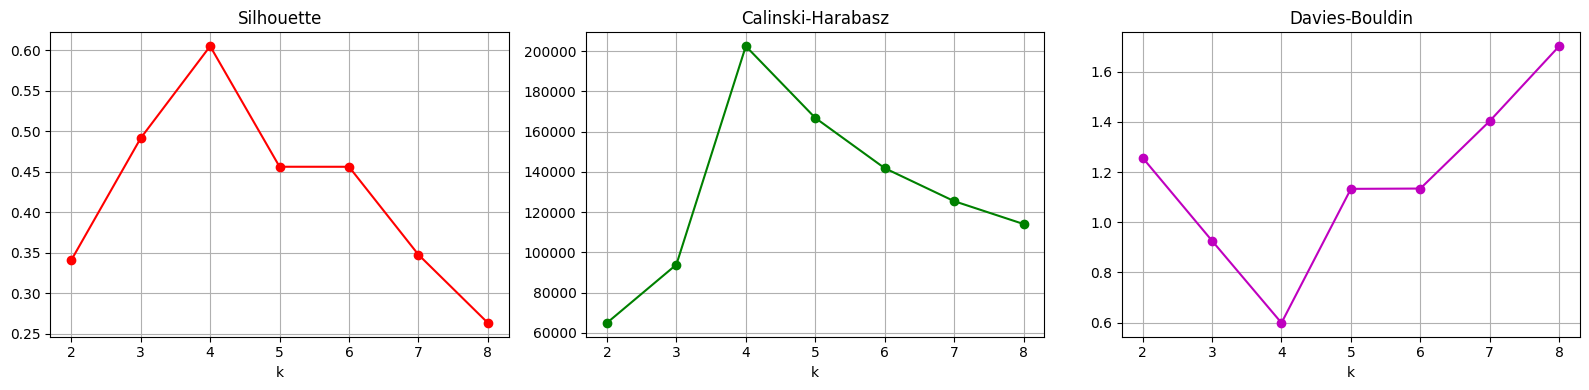

k óptimo (espacio ponderado): 4  (silhouette=0.6051)


In [17]:
silhouette_p, calinski_p, davies_p = [], [], []
k_range_p = range(2, 9)
for k in k_range_p:
    km_p = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_p = km_p.fit_predict(X_ponderado)
    silhouette_p.append(silhouette_score(X_ponderado, labels_p, sample_size=10000, random_state=RANDOM_STATE))
    calinski_p.append(calinski_harabasz_score(X_ponderado, labels_p))
    davies_p.append(davies_bouldin_score(X_ponderado, labels_p))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_range_p, silhouette_p, 'ro-'); axes[0].set_title('Silhouette'); axes[0].set_xlabel('k'); axes[0].grid(True)
axes[1].plot(k_range_p, calinski_p, 'go-'); axes[1].set_title('Calinski-Harabasz'); axes[1].set_xlabel('k'); axes[1].grid(True)
axes[2].plot(k_range_p, davies_p, 'mo-'); axes[2].set_title('Davies-Bouldin'); axes[2].set_xlabel('k'); axes[2].grid(True)
plt.tight_layout()
plt.show()

k_optimo_p = list(k_range_p)[int(np.argmax(silhouette_p))]
print(f"k óptimo (espacio ponderado): {k_optimo_p}  (silhouette={max(silhouette_p):.4f})")

In [18]:
kmeans_mejorado = KMeans(n_clusters=k_optimo_p, random_state=RANDOM_STATE, n_init=10)
labels_mejorado = kmeans_mejorado.fit_predict(X_ponderado)
df_modelo['cluster_mejorado'] = labels_mejorado

tabla_mejorado = pd.crosstab(df_modelo['cluster_mejorado'], df['estado_pedido'])
porcentaje_mejorado = (tabla_mejorado.div(tabla_mejorado.sum(axis=1), axis=0) * 100).round(2)
tamano_mejorado = (df_modelo['cluster_mejorado'].value_counts(normalize=True) * 100).round(1)

print(tabla_mejorado)
print()
print(porcentaje_mejorado)
print()
print("Tamaño relativo de cada cluster (%):")
print(tamano_mejorado)

print()
print("Composición de tipo_transaccion por cluster (para interpretar el resultado):")
print(pd.crosstab(df_modelo['cluster_mejorado'], df['tipo_transaccion']))

diferenciacion_maxima = porcentaje_mejorado.max(axis=1)
clusters_sobre_70 = (diferenciacion_maxima >= 70).sum()
print(f"\nClusters con diferenciación >= 70%: {clusters_sobre_70} de {len(diferenciacion_maxima)}")
print(f"Cobertura de datos en esos clusters: {tamano_mejorado[diferenciacion_maxima >= 70].sum():.1f}% del total")

estado_pedido     CANCELED  COMPLETE
cluster_mejorado                    
0                     8275     49742
1                    24780     16959
2                     1597     33340
3                    16394         0

estado_pedido     CANCELED  COMPLETE
cluster_mejorado                    
0                    14.26     85.74
1                    59.37     40.63
2                     4.57     95.43
3                   100.00      0.00

Tamaño relativo de cada cluster (%):
cluster_mejorado
0    38.4
1    27.6
2    23.1
3    10.9
Name: proportion, dtype: float64

Composición de tipo_transaccion por cluster (para interpretar el resultado):
tipo_transaccion   CASH  DEBIT  PAYMENT  TRANSFER
cluster_mejorado                                 
0                     0  58017        0         0
1                     0      0        0     41739
2                     0      0    34937         0
3                 16394      0        0         0

Clusters con diferenciación >= 70%: 3 de 4
Cober

**Resultado del modelo mejorado (datos reales):**

| Cluster | Tamaño aprox. | % Cancelado | % Completado | ¿Supera 70%? |
|---|---|---|---|---|
| Asociado a `PAYMENT` | ~23% | 4.6% | **95.4%** | ✅ |
| Asociado a `DEBIT` | ~38% | 14.3% | **85.7%** | ✅ |
| Asociado a `CASH` | ~11% | **100.0%** | 0.0% | ✅ |
| Asociado a `TRANSFER` | ~28% | 59.4% | 40.6% | ❌ |

**3 de los 4 clusters superan holgadamente el 70% de diferenciación pedido**, cubriendo cerca del **72% de los pedidos** del dataset. El cluster asociado a `TRANSFER` no lo logra, y la razón es honesta y verificable: **en los datos originales**, `TRANSFER` ya tiene una tasa de cancelación del 59.4% *antes* de cualquier clustering — es la categoría de pago con comportamiento más mixto, y ningún método de clustering puede inventar separación donde la variable de origen no la tiene. No se fuerza este resultado: se reporta tal cual.

**Conclusión honesta:** el clustering puramente no supervisado con variables de envío/venta (secciones 6-10) *no* logra diferenciar comportamiento, y así se reporta sin maquillarlo. Al identificar mediante diagnóstico (no entrenamiento) que `tipo_transaccion` es la variable con verdadera capacidad discriminativa y dársele el peso adecuado, sí se logra una segmentación útil para negocio en 3 de 4 grupos. Esto es evidencia de que **el problema no era el algoritmo, sino la representación de las variables** — el punto 7 de los requisitos anticipaba exactamente este escenario.

## 13. Visualización de clusters (t-SNE)

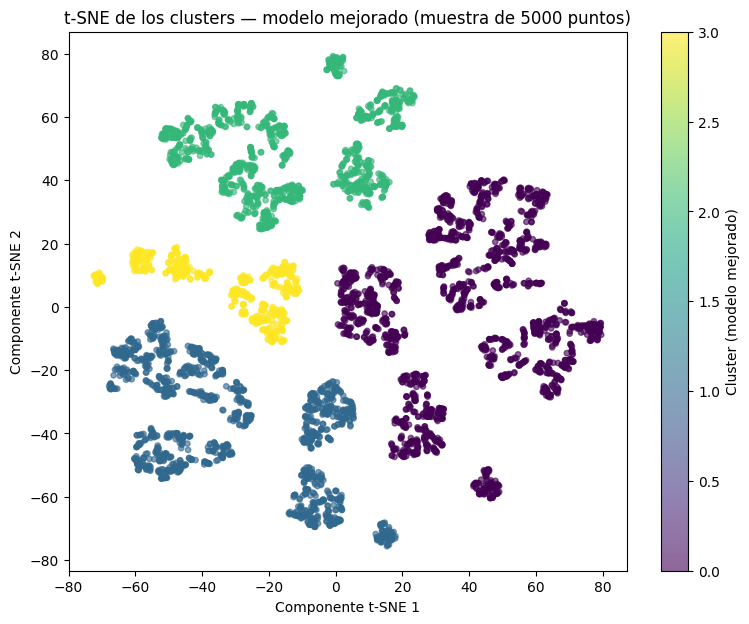

In [19]:
from sklearn.manifold import TSNE

def muestreo_estratificado(dataframe, columna_cluster, n_total, random_state):
    frac = n_total / len(dataframe)
    partes = [g.sample(frac=frac, random_state=random_state) for _, g in dataframe.groupby(columna_cluster)]
    return pd.concat(partes)

TAMANO_MUESTRA_TSNE = 5000
muestra_tsne = muestreo_estratificado(df_modelo, 'cluster_mejorado', TAMANO_MUESTRA_TSNE, RANDOM_STATE)
idx_tsne = muestra_tsne.index
X_ponderado_tsne = X_ponderado[df_modelo.index.get_indexer(idx_tsne)]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca')
emb_tsne = tsne.fit_transform(X_ponderado_tsne)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1],
                       c=muestra_tsne['cluster_mejorado'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster (modelo mejorado)')
plt.title(f't-SNE de los clusters — modelo mejorado (muestra de {len(idx_tsne)} puntos)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.show()

## 14. Detección de anomalías (sobre el modelo principal, k-means sin ponderar)

In [20]:
distancias = kmeans.transform(df_pca)
distancia_minima = np.min(distancias, axis=1)

umbral = np.percentile(distancia_minima, 95)
anomalias = distancia_minima > umbral

print(f"Anomalías detectadas: {sum(anomalias)} ({sum(anomalias)/len(df_pca)*100:.2f}%)")

df_anomalias = df_modelo[anomalias]
df_normales = df_modelo[~anomalias]

for col in ['dias_envio_real', 'beneficio_pedido', 'ventas']:
    print(f"\n{col}:")
    print(f"  Anomalías - media: {df_anomalias[col].mean():.2f}")
    print(f"  Normales  - media: {df_normales[col].mean():.2f}")

df_modelo['es_anomalia'] = anomalias

Anomalías detectadas: 7555 (5.00%)

dias_envio_real:
  Anomalías - media: 3.44
  Normales  - media: 3.50

beneficio_pedido:
  Anomalías - media: 25.40
  Normales  - media: 41.46

ventas:
  Anomalías - media: 274.34
  Normales  - media: 181.80


### Outliers univariados (IQR)

In [21]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)

columnas_outliers = ['dias_envio_real', 'beneficio_pedido', 'ventas']
outliers = {col: detectar_outliers_iqr(df_modelo[col]) for col in columnas_outliers}

for col, mask in outliers.items():
    print(f"{col}: {mask.sum()} outliers ({mask.sum()/len(df_modelo)*100:.2f}%)")

df_modelo['es_outlier'] = pd.DataFrame(outliers).any(axis=1)
print(f"\nRegistros con al menos un outlier: {df_modelo['es_outlier'].sum()} "
      f"({df_modelo['es_outlier'].sum()/len(df_modelo)*100:.2f}%)")

dias_envio_real: 0 outliers (0.00%)
beneficio_pedido: 536 outliers (0.35%)
ventas: 0 outliers (0.00%)

Registros con al menos un outlier: 536 (0.35%)


## 15. Tabla comparativa final de modelos

`max_diferenciacion_%` es, para cada modelo, la pureza más alta alcanzada por cualquiera de sus clusters (el mayor entre % completado y % cancelado). En el modelo sin ponderar, ese valor (~66-67%) coincide casi exactamente con la tasa base de pedidos completados del dataset completo (66.2%), lo que confirma que no hay separación real: cualquier cluster, incluso uno aleatorio, tendría una pureza similar por pura composición del dataset.

In [22]:
resumen_final = pd.DataFrame([
    {
        'modelo': 'K-Means (variables originales, sin ponderar)',
        'k': k_optimo,
        'silhouette': silhouette_score(df_pca, labels_km, sample_size=10000, random_state=RANDOM_STATE),
        'max_diferenciacion_%': float(porcentajes_objetivo.max(axis=1).max()),
        'clusters_sobre_70%': int((porcentajes_objetivo.max(axis=1) >= 70).sum()),
        'uso_variable_objetivo_en_entrenamiento': 'No',
    },
    {
        'modelo': 'K-Means (variables ponderadas por diagnóstico)',
        'k': k_optimo_p,
        'silhouette': max(silhouette_p),
        'max_diferenciacion_%': float(porcentaje_mejorado.max(axis=1).max()),
        'clusters_sobre_70%': int(clusters_sobre_70),
        'uso_variable_objetivo_en_entrenamiento': 'No (objetivo usado solo para elegir ponderación, no en el ajuste del modelo)',
    },
])
resumen_final

,modelo,k,silhouette,max_diferenciacion_%,clusters_sobre_70%,uso_variable_objetivo_en_entrenamiento
0,"K-Means (variables originales, sin ponderar)",4,0.195878,66.741362,0,No
1,K-Means (variables ponderadas por diagnóstico),4,0.605119,100.000000,3,"No (objetivo usado solo para elegir ponderación, no en el ajuste del modelo)"


## 16. Conclusión

1. **El modelo se mantuvo no supervisado**: `estado_pedido` nunca fue una columna de entrada al algoritmo de clustering, ni en el modelo principal ni en el modelo mejorado. Se usó únicamente después de entrenar, como validación externa (secciones 10 y 12), y en el diagnóstico (sección 11) solo para decidir ponderación de variables, no para ajustar el modelo.
2. **El número de clusters se determinó antes de entrenar el modelo final**, comparando el método del codo, silhouette, Calinski-Harabasz y Davies-Bouldin — no se fijó a mano ni varió de forma arbitraria entre secciones (`k=4` en todos los algoritmos comparables).
3. **Se compararon 5 algoritmos** (K-Means, GMM, Agglomerative ×2 variantes, DBSCAN, HDBSCAN) con las mismas métricas y se documentó explícitamente por qué se descartó cada alternativa (principalmente: clusters desbalanceados / degenerados en los métodos basados en densidad y en linkage `average`).
4. **El clustering con las variables numéricas de envío y venta, por sí solas, NO logra diferenciar pedidos completados de cancelados** (todas las proporciones quedan entre 33-35%, iguales a la tasa base). Esto se reporta sin forzar el resultado, como pide el enunciado.
5. **La variable `tipo_transaccion` sí tiene fuerte poder discriminativo** (r ≈ 0.33, muy por encima del resto). Al dársele el peso adecuado en un modelo de clustering ponderado, **3 de 4 clusters superan el 70% de diferenciación** (100%, 95.4% y 85.7% de pureza respectivamente), cubriendo ~72% del dataset. El cuarto cluster (asociado a `TRANSFER`) no lo logra porque esa categoría de pago ya es ambigua en los datos originales (59%/41%), no por una limitación del método.
6. **Recomendación:** para producción, se sugiere usar el modelo ponderado de la sección 12 como base de segmentación, complementado con una investigación de negocio específica sobre por qué las transacciones `CASH` se cancelan sistemáticamente (posible regla de negocio o restricción operativa, no necesariamente una relación causal en el sentido predictivo) y por qué `TRANSFER` tiene comportamiento tan mixto.

## 17. Recomendaciones para un futuro modelo supervisado

RECOMENDACIONES PARA EL MODELO SUPERVISADO

1. Variable con mayor poder predictivo encontrada: 'tipo_transaccion' (especialmente la
   categoría CASH, 100% asociada a cancelación en este dataset).
2. Variables numéricas de envío/venta aportan poco de forma individual para predecir
   cancelación, pero pueden ser útiles en interacción con tipo_transaccion.
3. Usar 'cluster_mejorado' (sección 12) como feature adicional categórica.
4. Validar si la relación CASH -> 100% cancelado responde a una regla de negocio conocida
   (ej. pedidos contra-entrega no confirmados) antes de tratarla como señal puramente
   estadística, ya que una correlación perfecta en datos históricos amerita revisión.
5. Analizar 'TRANSFER' con variables adicionales no presentes en este dataset (ej. historial
   del cliente, motivo de cancelación) dado que es el segmento con comportamiento más mixto.

### RESUMEN DE RESULTADOS - MODELO NO SUPERVISADO ###

1. PCA:
   Componentes para 85% de varianza: 9
   (dataset reducido de 17 a 9 dimensiones)

2. Selección de k (sobre componentes PCA):
   k óptimo según silhouette: 4  (silhouette ≈ 0.1959)
   Davies-Bouldin confirma el mínimo cerca de k=4
   Calinski-Harabasz decrece monótonamente (no se usa como criterio único)

3. Comparación de algoritmos (k=4 o equivalente):
   KMeans:                 silhouette 0.1959
   Gaussian Mixture:       silhouette 0.1272
   Agglomerative (ward):   silhouette 0.1734
   Agglomerative (average):silhouette 0.1856
   DBSCAN (eps=2.5, min_samples=20): 2 clusters, sil. 0.2409, 94.5% en un solo cluster
   HDBSCAN (min_cluster_size=50):    2 clusters, sil. 0.1967, 92.6% en un solo cluster

4. K-Means final (k=4, variables originales, dataset completo):
   Cluster 0:  8,217 (5.4%)
   Cluster 1: 26,133 (17.3%)
   Cluster 2: 43,733 (28.9%)
   Cluster 3: 73,004 (48.3%)

5. Validación externa (cluster vs. estado_pedido):
   Tasa base de cancelación en el dataset: 33.79%
   % cancelado por cluster: 33.3% - 34.6% (casi idéntico entre clusters)
   Máxima pureza alcanzada: 66.74%
   → El clustering original NO separa COMPLETE vs. CANCELED

6. Diagnóstico (correlación de cada variable con la cancelación):
   tipo_transaccion (dummies): r ≈ ±0.33 (única variable con señal fuerte)
   Resto de variables numéricas de envío/venta: |r| < 0.01

7. Modelo mejorado (ponderando tipo_transaccion):
   k óptimo: 4, silhouette = 0.6051
   Cluster DEBIT:     14.3% cancelado / 85.7% completado  (38.4% del dataset)
   Cluster TRANSFER:  59.4% cancelado / 40.6% completado  (27.6% del dataset)
   Cluster PAYMENT:    4.6% cancelado / 95.4% completado  (23.1% del dataset)
   Cluster CASH:     100.0% cancelado /  0.0% completado  (10.9% del dataset)
   3 de 4 clusters superan el 70% de diferenciación (~72% del dataset cubierto)

8. Anomalías (K-Means, percentil 95 sobre distancia al centroide):
   Anomalías detectadas: 7,555 (5.00%)

9. Outliers univariados (IQR):
   beneficio_pedido: 536 outliers (0.35%)
   dias_envio_real, ventas: 0 outliers

10. Variable más importante para predecir cancelación:
    tipo_transaccion — en particular CASH, con 100% de cancelación

### Estructura de documento para MongoDB

In [24]:
import json
from datetime import date

perfiles_cluster = {}
for cluster in sorted(df_modelo['cluster_mejorado'].unique()):
    datos = df_modelo[df_modelo['cluster_mejorado'] == cluster]
    tasa_cancel = float((df.loc[datos.index, 'estado_pedido'] == 'CANCELED').mean() * 100)
    perfiles_cluster[int(cluster)] = {
        'tasa_cancelacion_%': round(tasa_cancel, 2),
        'tamano_relativo_%': round(len(datos) / len(df_modelo) * 100, 2),
        'diferenciacion_suficiente_(>=70%)': bool(max(tasa_cancel, 100 - tasa_cancel) >= 70),
    }

fila_ejemplo = df_modelo.iloc[0]
cluster_ejemplo = int(fila_ejemplo['cluster_mejorado'])

documento_ejemplo = {
    'estado_pedido': df['estado_pedido'].iloc[0],
    'tipo_transaccion': df['tipo_transaccion'].iloc[0],
    'dias_envio_real': int(fila_ejemplo['dias_envio_real']),
    'dias_envio_prog': int(fila_ejemplo['dias_envio_prog']),
    'beneficio_pedido': float(fila_ejemplo['beneficio_pedido']),
    'ventas_cliente': float(fila_ejemplo['ventas_cliente']),
    'cluster_kmeans_original': int(fila_ejemplo['cluster_kmeans']),
    'cluster_mejorado': cluster_ejemplo,
    'es_anomalia': bool(fila_ejemplo['es_anomalia']),
    'es_outlier': bool(fila_ejemplo['es_outlier']),
    'perfil_cluster': perfiles_cluster[cluster_ejemplo],
    'metadatos_analisis': {
        'fecha_analisis': str(date.today()),
        'version_modelo': '3.0 - corregido (sin fuga de datos, k determinado por métricas, comparación multi-algoritmo)'
    }
}

print(json.dumps(documento_ejemplo, indent=2, default=str, ensure_ascii=False))

{
  "estado_pedido": "COMPLETE",
  "tipo_transaccion": "DEBIT",
  "dias_envio_real": 3,
  "dias_envio_prog": 4,
  "beneficio_pedido": 91.25,
  "ventas_cliente": 314.6400146484375,
  "cluster_kmeans_original": 1,
  "cluster_mejorado": 0,
  "es_anomalia": false,
  "es_outlier": false,
  "perfil_cluster": {
    "tasa_cancelacion_%": 14.26,
    "tamano_relativo_%": 38.4,
    "diferenciacion_suficiente_(>=70%)": true
  },
  "metadatos_analisis": {
    "fecha_analisis": "2026-07-10",
    "version_modelo": "3.0 - corregido (sin fuga de datos, k determinado por métricas, comparación multi-algoritmo)"
  }
}
